# MBRL Benchmark Plots

This notebook mirrors the DT/DT$^2$ benchmark plotting flow from `results.ipynb`, without FQE.

It adds model-based baselines loaded from `./test/{pipeline}/mlp/summary_{seed}.json`:
- `VaGraM`: `dynamics.value_aware` (from `summary_VAML_{seed}.json`)
- `MOReL`: `dynamics.morel_pessimistic`
- `MOPO`: `dynamics.mopo_penalized`
- `ROMI`: `dynamics.romi_model_return`
- `OMD`: `dynamics.omd`

Use `baseline_seed_ranges` in `plot_benchmarks_with_mbrl(...)` to assign distinct seed ranges per baseline.



In [2]:
import json
import os
import numpy as np
from scipy.stats import norm
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============== CONFIGURATION ==============
PIPELINE = "pendulum_pipeline"
SEEDS = list(range(0, 30))
TOP_K = 3
MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
# ===========================================

ARCH_METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"],
}

BASELINE_CONFIG = {
    "VaGraM": {
        "pattern": "./test/{pipeline}/mlp/summary_VAML_{seed}.json",
        "metric_paths": {
            "env_mc": ["env_mc"],
            "VaGraM": ["dynamics", "value_aware"],
        },
        "color": "grey",
        "edgecolor": "dimgrey",
        "label": r"$\mathrm{VaGraM}$",
    },
    "MOReL": {
        "pattern": "./camera_ready/{pipeline}/mlp/summary_{seed}.json",
        "metric_paths": {
            "env_mc": ["env_mc"],
            "MOReL": ["dynamics", "morel_pessimistic"],
        },
        "color": "#c8d28b",
        "edgecolor": "#69752b",
        "label": r"$\mathrm{MOReL}$",
    },
    "MOPO": {
        "pattern": "./camera_ready/{pipeline}/mlp/summary_{seed}.json",
        "metric_paths": {
            "env_mc": ["env_mc"],
            "MOPO": ["dynamics", "mopo_penalized"],
        },
        "color": "#f4b6a6",
        "edgecolor": "#9e3d30",
        "label": r"$\mathrm{MOPO}$",
    },
    "ROMI": {
        "pattern": "./test/{pipeline}/mlp/summary_{seed}.json",
        "metric_paths": {
            "env_mc": ["env_mc"],
            "ROMI": ["dynamics", "romi_model_return"],
        },
        "color": "#a9c2e8",
        "edgecolor": "#1f4a8a",
        "label": r"$\mathrm{ROMI}$",
    },
    "OMD": {
        "pattern": "./test/{pipeline}/mlp/summary_{seed}.json",
        "metric_paths": {
            "env_mc": ["env_mc"],
            "OMD": ["dynamics", "omd"],
        },
        "color": "#b7e4c7",
        "edgecolor": "#2d6a4f",
        "label": r"$\mathrm{OMD}$",
    },
    "HDTwin": {
        "label": r"$\mathrm{HDTwin}$",
        "color": (0.55, 0.55, 0.55),
        "edgecolor": (0.25, 0.25, 0.25),
    }
}


def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)
    theta_hat = stat_fn(data)

    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))
    return theta_hat, (lo, hi)


def get_nested_value(dictionary, keys):
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf


def process_single_seed(file_path, metric_paths, top_k=TOP_K, required_methods=None):
    required_methods = required_methods or []

    try:
        with open(file_path, "r") as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None

    results = data.get("results", [])
    if not results:
        return None

    scores = {m: [] for m in metric_paths.keys()}
    for entry in results:
        for method, path in metric_paths.items():
            scores[method].append(get_nested_value(entry, path))

    for method in scores:
        scores[method] = np.array(scores[method])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    for method in required_methods:
        values = scores.get(method)
        if values is None or np.all(np.isinf(values)):
            return None

    true_values = scores["env_mc"]
    finite_true_values = true_values[~np.isinf(true_values)]
    if finite_true_values.size == 0:
        return None
    true_optimal_val = np.max(finite_true_values)

    output = {"rankings": {}, "regrets": {}, "topk_regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        output["rankings"][method] = ranking.tolist()
        if method == "env_mc":
            continue

        selected_idx = ranking[0]
        selected_true = true_values[selected_idx]
        regret = np.nan if np.isinf(selected_true) else true_optimal_val - selected_true
        output["regrets"][method] = float(regret)

        k_eff = min(top_k, len(ranking))
        topk_idx = ranking[:k_eff]
        topk_true = true_values[topk_idx]
        finite_topk_true = topk_true[~np.isinf(topk_true)]
        if finite_topk_true.size == 0:
            topk_regret = np.nan
        else:
            topk_regret = true_optimal_val - np.max(finite_topk_true)
        output["topk_regrets"][method] = float(topk_regret)

    return output


def aggregate_architecture_results(seed_range, folder, pipeline=PIPELINE, top_k=TOP_K):
    pattern = f"./test/{pipeline}/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in ARCH_METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in ARCH_METRIC_PATHS.keys() if m != "env_mc"}
    agg_topk_regrets = {m: [] for m in ARCH_METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []

    print(f"Processing {folder} seeds {list(seed_range)}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename, ARCH_METRIC_PATHS, top_k=top_k)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings:
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets:
            agg_regrets[method].append(single_res["regrets"][method])
            agg_topk_regrets[method].append(single_res["topk_regrets"][method])

    return agg_rankings, agg_regrets, agg_topk_regrets, valid_seeds


def aggregate_baseline_results(seed_range, baseline_name, pipeline=PIPELINE, top_k=TOP_K):
    cfg = BASELINE_CONFIG[baseline_name]
    metric_paths = cfg["metric_paths"]
    agg_rankings = {m: [] for m in metric_paths.keys()}
    agg_regrets = {baseline_name: []}
    agg_topk_regrets = {baseline_name: []}
    valid_seeds = []

    print(f"Processing {baseline_name} seeds {list(seed_range)}...")
    for seed in seed_range:
        filename = cfg["pattern"].format(pipeline=pipeline, seed=seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(
            filename,
            metric_paths,
            top_k=top_k,
            required_methods=[baseline_name],
        )
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings:
            agg_rankings[method].append(single_res["rankings"][method])
        agg_regrets[baseline_name].append(single_res["regrets"][baseline_name])
        agg_topk_regrets[baseline_name].append(single_res["topk_regrets"][baseline_name])

    return agg_rankings, agg_regrets, agg_topk_regrets, valid_seeds


def collect_performance_bca(rankings, regrets, methods, topk_regrets=None, n_boot=10000, regret_metric="regret"):
    if regret_metric not in ["regret", "topk_regret"]:
        raise ValueError("regret_metric must be either 'regret' or 'topk_regret'.")

    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        ranks = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            ranks[idx] = rank
        return ranks

    true_rankings = rankings.get("env_mc", [])
    regret_source = topk_regrets if regret_metric == "topk_regret" else regrets

    for method in methods:
        if method not in rankings or method not in regret_source:
            continue

        reg_values = np.asarray(regret_source[method], dtype=float)
        reg_values = reg_values[~np.isnan(reg_values)]
        if reg_values.size == 0:
            continue

        reg_mean, reg_ci = bca_ci(reg_values, n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []

        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            if not np.isnan(corr):
                spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)

        if len(spearman_scores) == 0:
            continue

        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)

        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }

    return results



In [3]:
HDTWIN_RESULTS = {
    "pendulum_pipeline": {
        "regret": (13.85, (13.85 - 6.55, 13.85 + 6.55)),
        "spearman": (-0.10, (-0.10 - 0.21, -0.10 + 0.21)),
    },
    "lunarlander_pipeline": {
        "regret": (49.10, (49.10 - 39.01, 49.10 + 39.01)),
        "spearman": (0.54, (0.54 - 0.18, 0.54 + 0.18)),
    },
    "hopper_pipeline": {
        "regret": (0.94, (0.94 - 0.49, 0.94 + 0.49)),
        "spearman": (0.40, (0.40 - 0.11, 0.40 + 0.11)),
    },
    "walker_pipeline": {
        "regret": (7.50, (7.50 - 1.15, 7.50 + 1.15)),
        "spearman": (-0.13, (-0.13 - 0.16, -0.13 + 0.16)),
    },
    "cheetah_pipeline": {
        "regret": (5.32, (5.32 - 2.04, 5.32 + 2.04)),
        "spearman": (0.16, (0.16 - 0.23, 0.16 + 0.23)),
    },
    "ant_pipeline": {
        "regret": (6.18, (6.18 - 2.07, 6.18 + 2.07)),
        "spearman": (0.24, (0.24 - 0.15, 0.24 + 0.15)),
    },
}

def format_folder_name(name):
    if name.lower() == "gru":
        return r"$\mathrm{GRU}$"
    if name.lower() == "mlp":
        return r"$\mathrm{MLP}$"
    if name.lower() == "ode":
        return r"$\mathrm{NODE}$"
    if name.lower() == "resnet":
        return r"$\mathrm{ResNet}$"
    return rf"$\mathrm{{{name.capitalize()}}}$"


def plot_benchmarks_with_mbrl(
    pipeline=PIPELINE,
    seeds=SEEDS,
    ylim=1.5,
    save=False,
    show_x_labels=True,
    regret_metric="regret",
    top_k=TOP_K,
    baselines=("VaGraM", "MOReL", "MOPO", "ROMI", "OMD", "HDTwin"),
    baseline_seed_ranges=None,
    best_arch_only=False,
):
    baseline_seed_ranges = baseline_seed_ranges or {}

    regret_label = r"$\mathrm{Regret}$" if regret_metric == "regret" else rf"$\mathrm{{Top-{top_k}\ Regret}}$"
    metrics = [("regret", regret_label), ("spearman", r"$\mathrm{Spearman}$")]

    results_by_folder = {}
    for folder in MODEL_FOLDERS:
        rankings, regrets, topk_regrets, processed_seeds = aggregate_architecture_results(
            seeds, folder, pipeline, top_k=top_k
        )
        if not processed_seeds:
            print(f"No valid seeds for {folder}; skipping.")
            continue
        results_by_folder[folder] = collect_performance_bca(
            rankings,
            regrets,
            methods=("supervised", "kendall"),
            topk_regrets=topk_regrets,
            n_boot=10000,
            regret_metric=regret_metric,
        )

    baseline_results = {}
    for baseline_name in baselines:
        if baseline_name not in BASELINE_CONFIG:
            continue


        # ------------------------------------------------------------------
        # Hard-coded HDTwin results
        # ------------------------------------------------------------------
        if baseline_name == "HDTwin":
            if pipeline not in HDTWIN_RESULTS:
                print(f"No HDTwin results for pipeline '{pipeline}'")
                continue

            baseline_results["HDTwin"] = {
                "regret": HDTWIN_RESULTS[pipeline]["regret"],
                "spearman": HDTWIN_RESULTS[pipeline]["spearman"],
            }
            continue

        baseline_seeds = baseline_seed_ranges.get(baseline_name, seeds)
        b_rankings, b_regrets, b_topk_regrets, b_seeds = aggregate_baseline_results(
            baseline_seeds,
            baseline_name,
            pipeline,
            top_k=top_k,
        )
        if not b_seeds:
            print(f"No valid seeds for {baseline_name}; skipping.")
            continue

        stats_out = collect_performance_bca(
            b_rankings,
            b_regrets,
            methods=(baseline_name,),
            topk_regrets=b_topk_regrets,
            n_boot=10000,
            regret_metric=regret_metric,
        )
        if baseline_name in stats_out:
            baseline_results[baseline_name] = stats_out[baseline_name]

    methods = ["supervised", "kendall"]
    methods_best_order = ["kendall", "supervised"]  # DT^2 first in best_arch_only mode
    folders = list(results_by_folder.keys())
    active_baselines = [b for b in baselines if b in baseline_results]

    if not folders:
        print("No results to plot.")
        return

    def _best_folder_by_regret(method_name):
        best_folder = None
        best_regret = np.inf
        for folder in folders:
            res = results_by_folder.get(folder, {})
            if method_name not in res:
                continue
            regret_mean, _ = res[method_name]["regret"]
            if np.isnan(regret_mean):
                continue
            if regret_mean < best_regret:
                best_regret = regret_mean
                best_folder = folder
        return best_folder

    bar_specs = []
    positions = []
    folder_label_positions = []
    folder_label_names = []

    if best_arch_only:
        best_spacing = 2.2
        for i, method in enumerate(methods_best_order):
            best_folder = _best_folder_by_regret(method)
            if best_folder is None:
                print(f"No valid architecture for method '{method}' when selecting best by regret.")
                continue
            bar_specs.append((best_folder, method))
            x = float(i) * best_spacing
            positions.append(x)

        if not bar_specs:
            print("No DT/DT2 bars to plot after best-architecture selection.")
            return

        selected = {method: folder for folder, method in bar_specs}
        print(f"Best architecture by regret: {selected}")
    else:
        group_gap = 0.6
        group_size = len(methods)
        centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]

        for i, folder in enumerate(folders):
            base = i * (group_size + group_gap)
            for j, method in enumerate(methods):
                positions.append(base + j)
                bar_specs.append((folder, method))
        folder_label_positions = centers
        folder_label_names = folders

    baseline_positions = {}
    if active_baselines:
        baseline_gap = 2.2 if not best_arch_only else best_spacing
        baseline_start = positions[-1] + baseline_gap
        for i, baseline_name in enumerate(active_baselines):
            baseline_positions[baseline_name] = baseline_start + i * baseline_gap

    palette = [
        (90 / 255, 180 / 255, 150 / 255),
        (220 / 255, 120 / 255, 90 / 255),
        (76 / 255, 120 / 255, 168 / 255),
        (114 / 255, 183 / 255, 178 / 255),
        (178 / 255, 121 / 255, 162 / 255),
        (238 / 255, 202 / 255, 59 / 255),
    ]

    folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
    hatch_map = {"supervised": "//", "kendall": None}
    best_method_colors = {
        "supervised": (76 / 255, 120 / 255, 168 / 255),
        "kendall": (220 / 255, 120 / 255, 90 / 255),
    }

    face_colors = []
    edge_colors = []
    hatches = []
    for folder, method in bar_specs:
        base_color = folder_colors[folder]
        if best_arch_only:
            method_color = best_method_colors.get(method, base_color)
            face_colors.append(method_color)
            edge_colors.append(method_color)
            hatches.append(None)
        elif method == "supervised":
            face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
            edge_colors.append(base_color)
            hatches.append(hatch_map[method])
        else:
            face_colors.append(base_color)
            edge_colors.append(base_color)
            hatches.append(hatch_map[method])

    fig_width = max(8, 2.2 * len(bar_specs) + 3 + 1.2 * len(active_baselines))
    fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(fig_width, 8), sharex=True)
    plot_title = pipeline.replace("_pipeline", "").replace("_", " ").title()
    axes[0].set_title(plot_title, fontsize=32)

    for ax, (metric, ylabel) in zip(axes, metrics):
        means = []
        lowers = []
        uppers = []

        for folder, method in bar_specs:
            res = results_by_folder[folder]
            if method not in res:
                means.append(np.nan)
                lowers.append(np.nan)
                uppers.append(np.nan)
                continue
            mean, ci = res[method][metric]
            means.append(mean)
            lowers.append(mean - ci[0])
            uppers.append(ci[1] - mean)

        for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
            ax.bar(
                pos,
                mean,
                yerr=[[lo], [up]],
                capsize=5,
                color=[fc],
                edgecolor=ec,
                hatch=hatch,
                linewidth=1,
                rasterized=True,
            )

        for baseline_name in active_baselines:
            mean, ci = baseline_results[baseline_name][metric]
            lo = mean - ci[0]
            up = ci[1] - mean
            cfg = BASELINE_CONFIG[baseline_name]
            ax.bar(
                baseline_positions[baseline_name],
                mean,
                yerr=[[lo], [up]],
                capsize=5,
                color=cfg["color"],
                edgecolor=cfg["edgecolor"],
                linewidth=1,
                rasterized=True,
            )

        ax.set_ylabel(ylabel, fontsize=28)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.tick_params(axis="y", labelsize=20)
        if metric == "regret":
            ax.set_ylim(0, ylim)

    if show_x_labels:
        bar_labels = []
        if best_arch_only:
            method_labels = {"supervised": r"$\mathrm{NLL}$", "kendall": r"$\mathrm{DT}^2$"}
            for _folder, method in bar_specs:
                bar_labels.append(method_labels.get(method, method))
        else:
            for _ in folders:
                bar_labels.extend([r"$\mathrm{DT}$", r"$\mathrm{DT}^2$"])
        for baseline_name in active_baselines:
            bar_labels.append(BASELINE_CONFIG[baseline_name]["label"])

        all_positions = positions + [baseline_positions[b] for b in active_baselines]
        axes[-1].set_xticks(all_positions)
        axes[-1].set_xticklabels(bar_labels, rotation=0, ha="center", fontsize=24)

        if not best_arch_only:
            trans = axes[-1].get_xaxis_transform()
            for center, folder in zip(folder_label_positions, folder_label_names):
                axes[-1].text(center, -0.14, format_folder_name(folder), transform=trans, ha="center", va="top", fontsize=28)
    else:
        axes[-1].set_xticks([])
        axes[-1].set_xticklabels([])

    fig.tight_layout()
    if save:
        suffix = "" if regret_metric == "regret" else f"_top{top_k}"
        plt.savefig(f"plots/{pipeline}_all{suffix}.pdf")


Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing MOReL seeds [3000, 3001, 3002, 3003, 3004, 3005, 3006, 3007, 3008, 3009]...
Processing MOPO seeds [3010, 3011, 3012, 3013, 3014, 3015, 3016, 3017, 3018, 3019]...
Processing ROMI seeds [4000, 4001, 4002, 4003, 4004, 4007, 4008]...
Processing OMD seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
No valid seeds for OMD; skipping.
Best architecture by regret: {'kendall': 'ode', 'supervised': 'ode'}


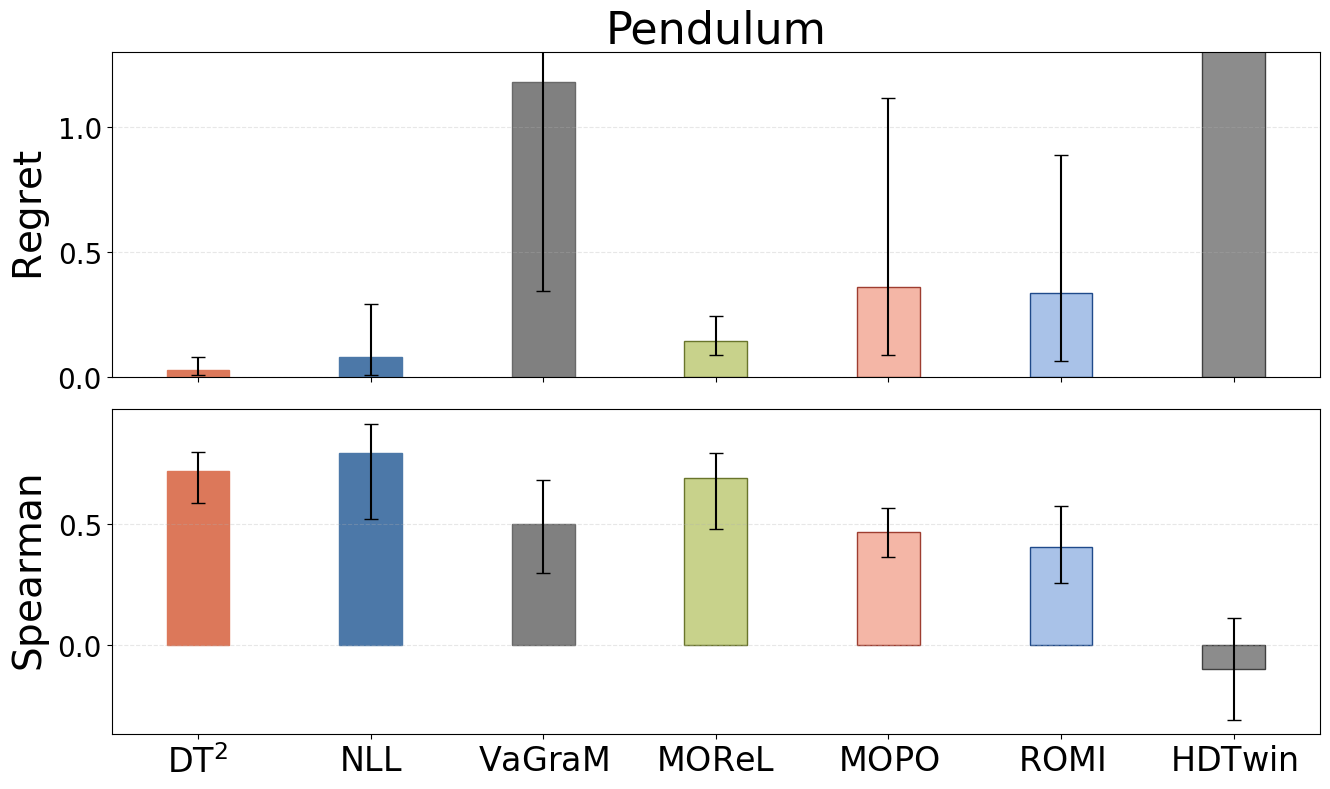

In [6]:
# Distinct seed ranges per baseline can be passed here.
# For MOReL/MOPO/ROMI/OMD, use whatever numeric seed IDs correspond to your result files.
example_baseline_seed_ranges = {
    "VaGraM": list(range(0, 10)),
    "MOReL": list(range(3000, 3010)),
    "MOPO": list(range(3010, 3020)),
    "ROMI": [4000, 4001, 4002, 4003, 4004, 4007, 4008],
    #"OMD": list(range(5000, 5005)),
}

plot_benchmarks_with_mbrl(
    pipeline="pendulum_pipeline",
    seeds=list(range(0, 10)),
    baseline_seed_ranges=example_baseline_seed_ranges,
    best_arch_only=True,  
    save=False,
    ylim=1.3,
    show_x_labels=True,
    regret_metric="regret",
    top_k=TOP_K,
)

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing MOReL seeds [3000, 3001, 3002, 3003, 3004, 3005, 3006, 3007, 3008, 3009]...
No valid seeds for MOReL; skipping.
Processing MOPO seeds [3010, 3011, 3012, 3013, 3014, 3015, 3016, 3017, 3018, 3019]...
No valid seeds for MOPO; skipping.
Processing ROMI seeds [4000, 4001, 4002, 4003, 4004, 4007, 4008]...
Processing OMD seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
No valid seeds for OMD; skipping.
Best architecture by regret: {'kendall': 'gru', 'supervised': 'transformer'}


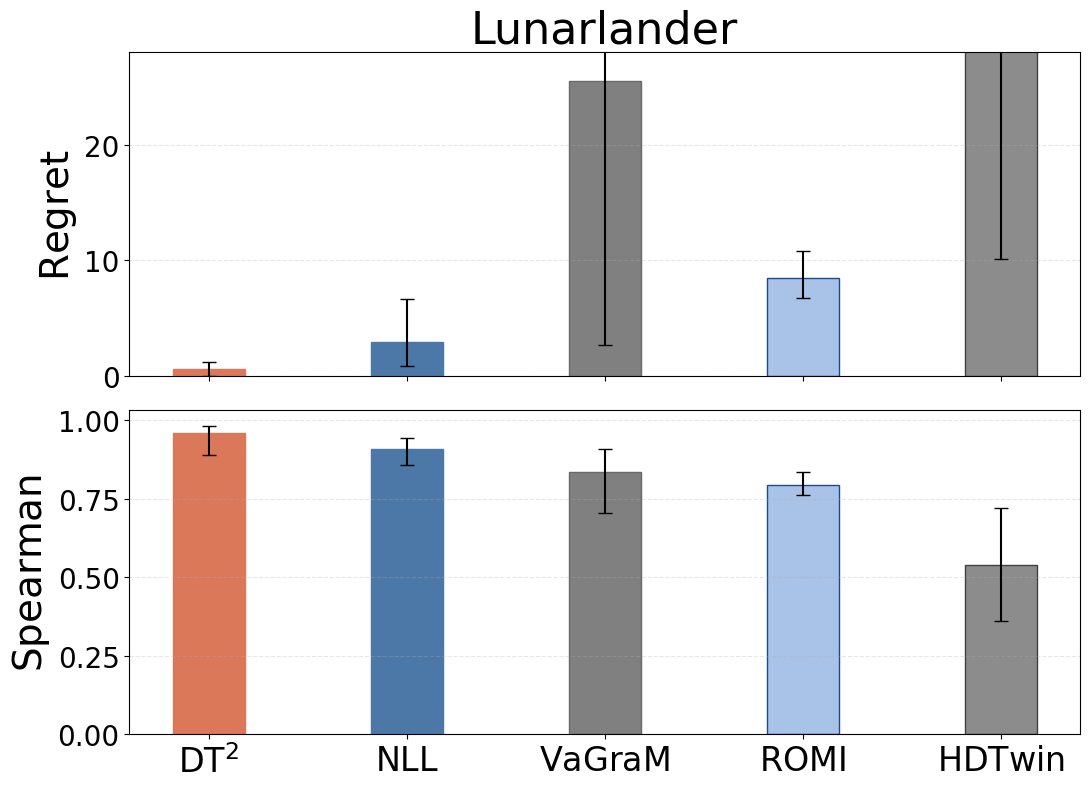

In [23]:
plot_benchmarks_with_mbrl(
    pipeline="lunarlander_pipeline",
    seeds=list(range(0, 10)),
    baseline_seed_ranges=example_baseline_seed_ranges,
    best_arch_only=True, 
    ylim=28,
    save=False,
    show_x_labels=True,
    regret_metric="regret",
    top_k=TOP_K,
)


Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing MOReL seeds [3000, 3001, 3002, 3003, 3004, 3005, 3006, 3007, 3008, 3009]...
No valid seeds for MOReL; skipping.
Processing MOPO seeds [3010, 3011, 3012, 3013, 3014, 3015, 3016, 3017, 3018, 3019]...
No valid seeds for MOPO; skipping.
Processing ROMI seeds [4000, 4001, 4002, 4003, 4004, 4007, 4008]...
Processing OMD seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
No valid seeds for OMD; skipping.
Best architecture by regret: {'kendall': 'transformer', 'supervised': 'ode'}


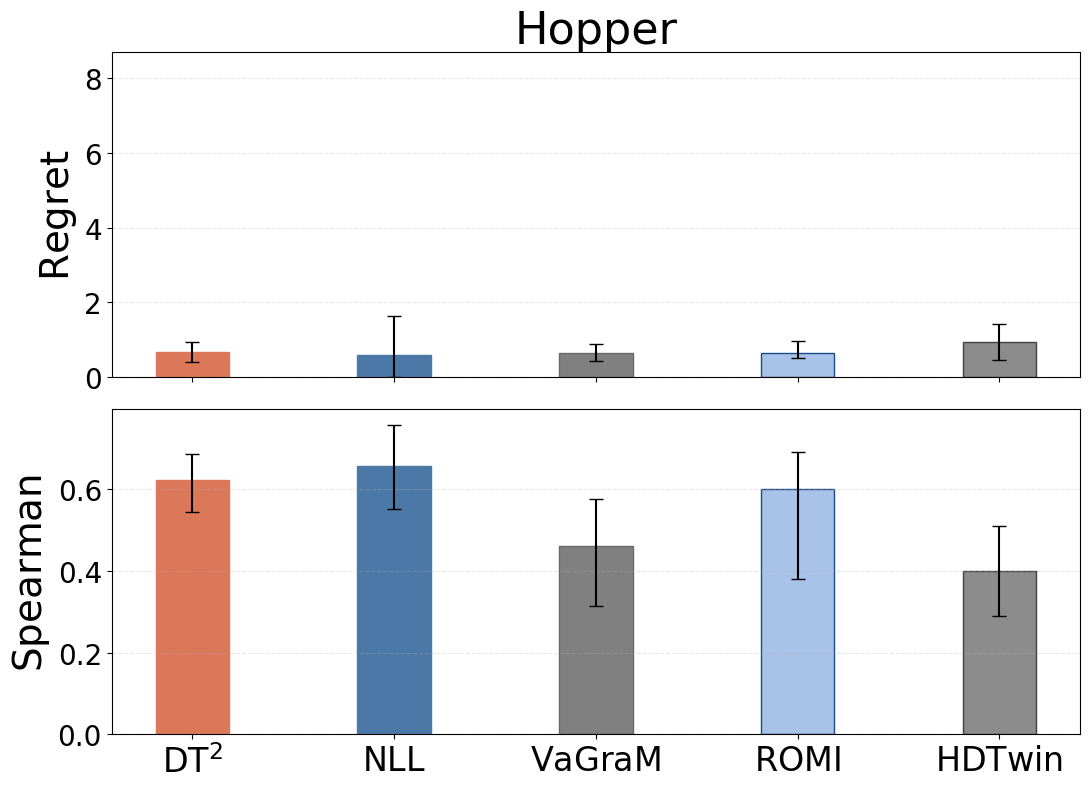

In [25]:
plot_benchmarks_with_mbrl(
    pipeline="hopper_pipeline",
    seeds=list(range(0, 10)),
    baseline_seed_ranges=example_baseline_seed_ranges,
    best_arch_only=True, 
    ylim=8.7,
    save=False,
    show_x_labels=True,
    regret_metric="regret",
    top_k=TOP_K,
)


Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing VaGraM seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing MOReL seeds [3000, 3001, 3002, 3003, 3004, 3005, 3006, 3007, 3008, 3009]...
Processing MOPO seeds [3010, 3011, 3012, 3013, 3014, 3015, 3016, 3017, 3018, 3019]...
Processing ROMI seeds [4000, 4001, 4002, 4003, 4004, 4007, 4008]...
Processing OMD 

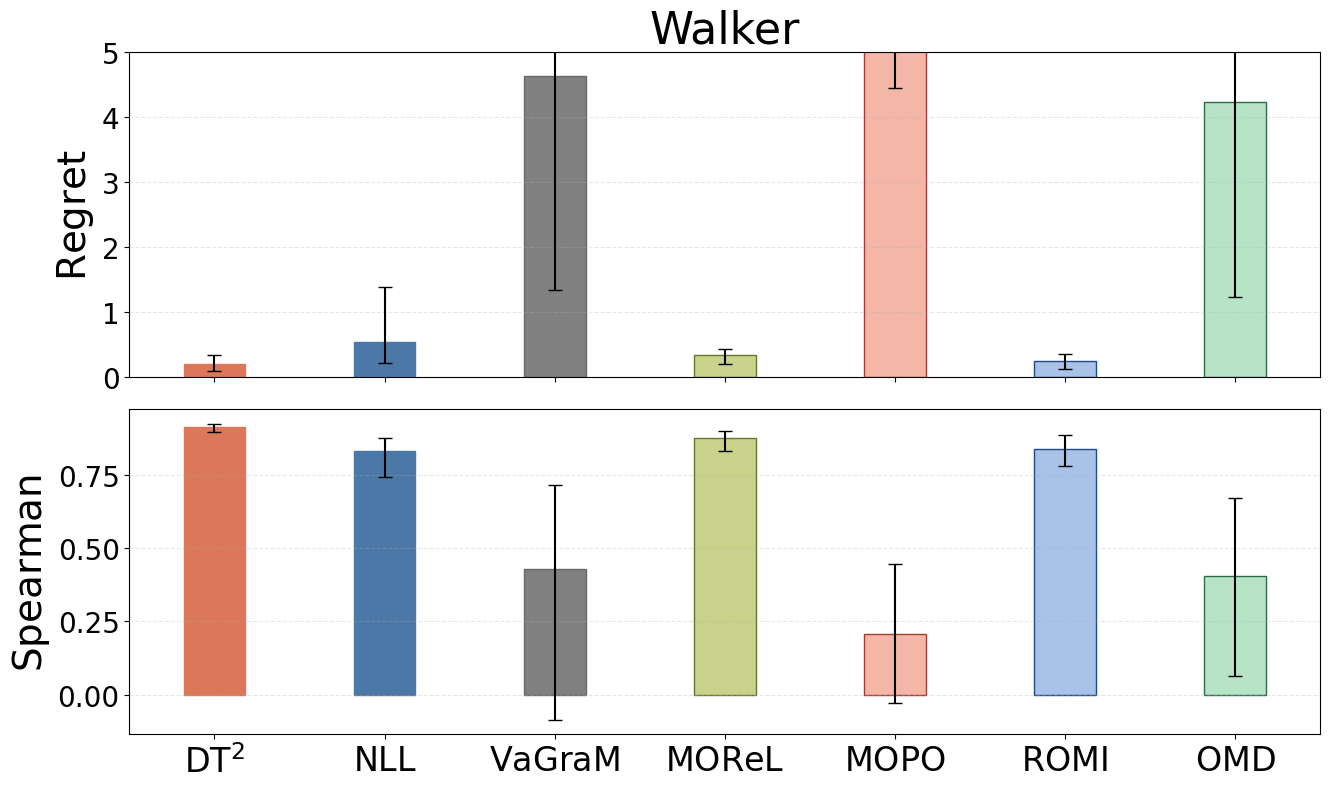

In [55]:
plot_benchmarks_with_mbrl(
    pipeline="walker_pipeline",
    seeds=list(range(0, 30)),
    baseline_seed_ranges=example_baseline_seed_ranges,
    best_arch_only=True, 
    ylim=5,
    save=True,
    show_x_labels=True,
    regret_metric="regret",
    top_k=TOP_K,
)


Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing VaGraM seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing MOReL seeds [3000, 3001, 3002, 3003, 3004, 3005, 3006, 3007, 3008, 3009]...
Processing MOPO seeds [3010, 3011, 3012, 3013, 3014, 3015, 3016, 3017, 3018, 3019]...
Processing ROMI seeds [4000, 4001, 4002, 4003, 4004, 4007, 4008]...
Processing OMD 

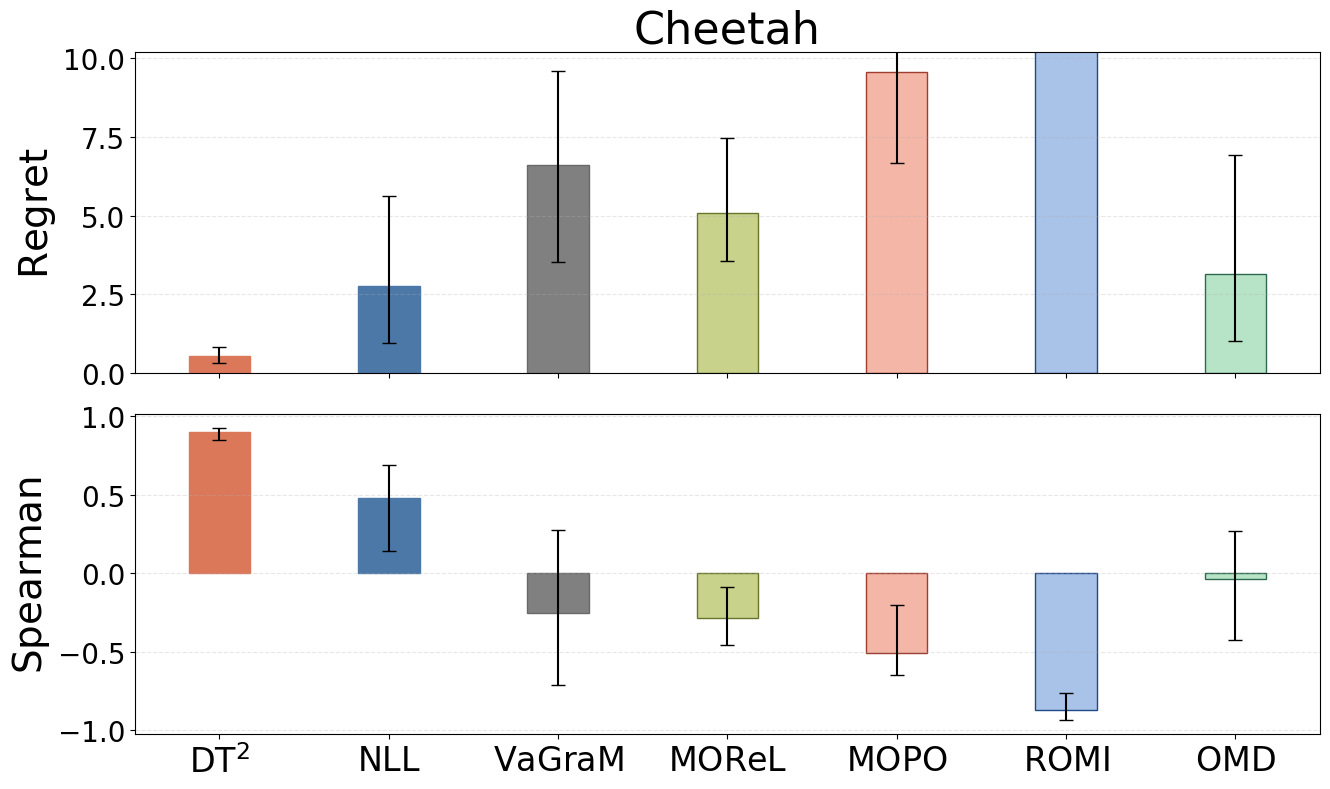

In [56]:
plot_benchmarks_with_mbrl(
    pipeline="cheetah_pipeline",
    seeds=list(range(0, 30)),
    baseline_seed_ranges=example_baseline_seed_ranges,
    best_arch_only=True, 
    ylim=10.2,
    save=True,
    show_x_labels=True,
    regret_metric="regret",
    top_k=TOP_K,
)


Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing VaGraM seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing MOReL seeds [3000, 3001, 3002, 3003, 3004, 3005, 3006, 3007, 3008, 3009]...
No valid seeds for MOReL; skipping.
Processing MOPO seeds [3010, 3011, 3012, 3013, 3014, 3015, 3016, 3017, 3018, 3019]...
No valid seeds for MOPO; skipping.
Processing ROMI seeds [4000, 4001, 4002, 4003, 4004, 4007, 4008]...
Processing OMD seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
No valid seeds for OMD; skipping.
Best architecture by regret: {'kendall': 'gru', 'supervised': 'gru'}


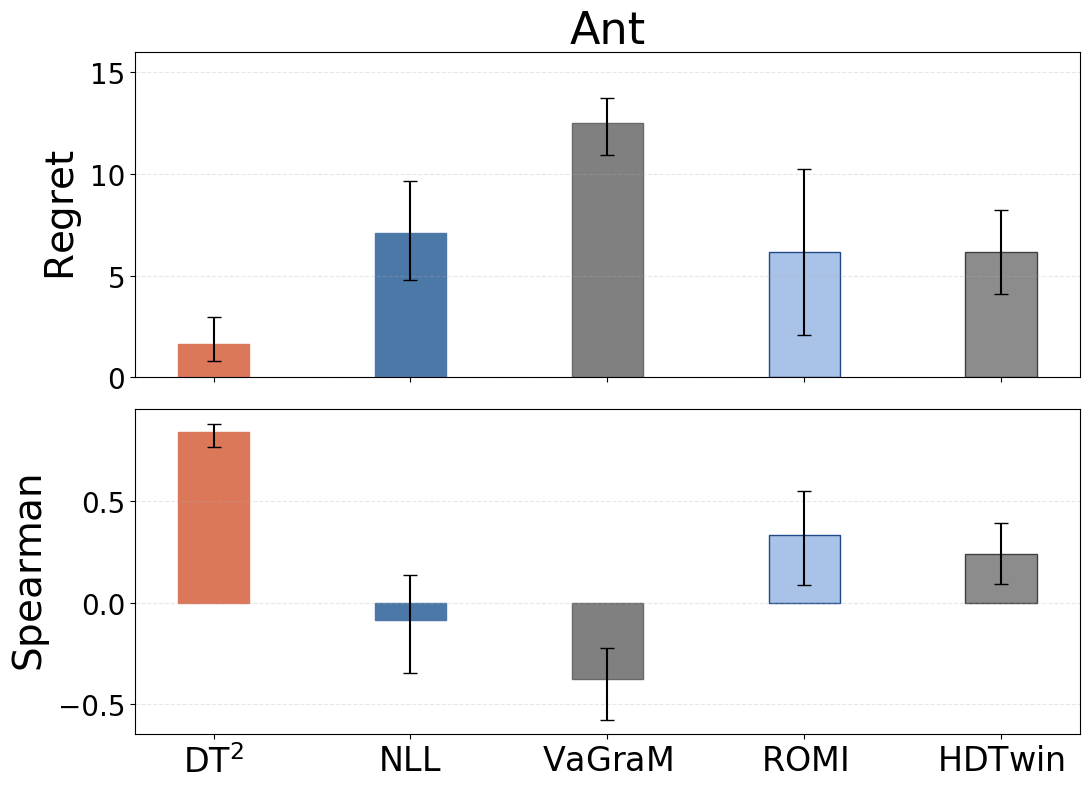

In [26]:
plot_benchmarks_with_mbrl(
    pipeline="ant_pipeline",
    seeds=list(range(0, 10)),
    baseline_seed_ranges=example_baseline_seed_ranges,
    best_arch_only=True, 
    ylim=16,
    save=False,
    show_x_labels=True,
    regret_metric="regret",
    top_k=TOP_K,
)